# Part I - Exploring the Infrared Fingerprints of Polycyclic Aromatic Hydrocarbons (PAHs)
## by Frederic Petrignani

## Introduction


This report explores a dataset of **polycyclic aromatic hydrocarbons (PAHs)** — flat, fused-ring carbon molecules that are among the most abundant complex molecules in the interstellar medium. Every PAH has a characteristic **infrared (IR) emission spectrum**: a set of discrete emission lines, each produced by a specific vibration of the molecule. That spectrum is effectively the molecule's fingerprint, and it is the phenomenon this project is built around.

### The data

The dataset combines two sources, merged and cleaned in a prior data-wrangling project ([thebreadishard/udacity-data-wrangling](https://github.com/thebreadishard/udacity-data-wrangling)):

- **NASA Ames PAH IR Spectroscopic Database (PAHdb)** — theoretical IR spectra (emission-line frequencies and intensities) and the molecule's ionization state. Source: https://www.astrochemistry.org/pahdb/
- **PubChem** (PUG REST API, NCBI/NIH) — molecular structure and size descriptors (molecular weight, heavy-atom count, `SMILES`, `InChIKey`, name). Source: https://pubchem.ncbi.nlm.nih.gov/

The cleaned data is stored as two tidy tables that we use here as **input**:

| Table | Grain | Rows | Key columns |
| --- | --- | --- | --- |
| `pah_molecules_clean.csv` | one row per molecule (per charge state) | 1,136 | `uid`, `formula_clean`, `charge_state`, `n_lines`, `MolecularWeight`, `HeavyAtomCount`, `SMILES`, `InChIKey`, `IUPACName` |
| `pah_transitions_clean.csv` | one row per IR emission line | 22,710 | `uid`, `frequency` (cm⁻¹), `intensity` |

The two tables link on `uid`: each molecule owns many transitions (emission lines), and `n_lines` on the molecule table is the count of those lines.

> **A note on line *counts* (why we don't ask "does size predict the number of lines?").** For a non-linear molecule with *N* atoms, the number of vibrational modes — and hence the number of emission lines — is fixed at **3*N* − 6**. For example naphthalene (C₁₀H₈) has 18 atoms → 3(18) − 6 = **48**, which is exactly its `n_lines`. So the *number* of lines is essentially a deterministic function of molecular size, not a finding to be discovered (the predecessor wrangling project reached the same conclusion and called that relationship "partly trivial"). This exploration therefore focuses on the **positions** (`frequency`) and **strengths** (`intensity`) of the lines — and how those depend on ionization — rather than on the line count itself.

### Questions this exploration will answer

1. **Distributions** — How are the key molecular properties distributed (molecular weight, heavy-atom count, and number of emission lines), and where do the emission lines themselves fall in **frequency** and **intensity**?
2. **Ionization** — Do **neutral, cation, and anion** forms differ in the **position** and **intensity** of their emission lines (the properties ionization *can* change, unlike the line count)?
3. **Spectral structure** — Which **frequency regions** carry the strongest emission, and how does that depend on molecular size and charge state?
4. **Structure ↔ spectrum (the stand-out goal)** — How can we best **visualize the connection between a molecule's vibrations and the lines in its spectrum** — pairing the molecule's structure with the IR spectrum so that a given vibration can be tied to the emission line it produces? Two representations serve two purposes: a **2D** structural diagram (colored atoms and bonds) for the static PDF fact sheet, and an interactive **3D** view in the notebook, where **out-of-plane** vibrations — which produce some of the strongest, most diagnostic PAH bands (the C–H bending modes near 700–900 cm⁻¹) — can actually be seen.

### Feature of interest

The main feature of interest is the **character of a molecule's IR emission lines** — their `frequency` and `intensity` — rather than their count. The features expected to support that investigation are `MolecularWeight`, `HeavyAtomCount`, and `charge_state`. Question 4 sets the project's overarching aim — a per-molecule "fact sheet" that pairs a molecule's structure with its IR spectrum — and the distribution and relationship questions (1–3) each feed into it.


## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

# Consistent, readable defaults for the whole report.
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


We load the two cleaned tables produced by the [wrangling project](https://github.com/thebreadishard/udacity-data-wrangling) — `pah_molecules_clean.csv` (molecule level) and `pah_transitions_clean.csv` (one row per IR emission line) — from `data/clean/`. Both are already tidy, so preliminary wrangling here is light and focuses on three things:

1. **Confirm structure and integrity** — shapes, data types, and missing values.
2. **Resolve a grain subtlety** — the molecule table has more rows than distinct PAHdb species, because the upstream merge matched species to PubChem by molecular *formula* and structural isomers share a formula. We build a species-level view for molecule-level distributions.
3. **Encode ordinal data correctly** — `charge_state` is made an ordered categorical (anion → neutral → cation) so later plots and summaries respect ionization order.


In [2]:
# Locate the cleaned data directory whether the notebook is run from the repo root
# or from the notebooks/ subfolder.
DATA_DIR = Path("../data/clean")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/clean")


def load_clean_table(filename):
    """Load a cleaned CSV from the data/clean directory into a DataFrame."""
    return pd.read_csv(DATA_DIR / filename)


# The two tidy input tables from the wrangling project.
molecules = load_clean_table("pah_molecules_clean.csv")      # molecule level
transitions = load_clean_table("pah_transitions_clean.csv")  # one row per emission line

print(f"molecules:   {molecules.shape[0]:,} rows x {molecules.shape[1]} cols")
print(f"transitions: {transitions.shape[0]:,} rows x {transitions.shape[1]} cols")


molecules:   1,136 rows x 12 cols
transitions: 22,710 rows x 3 cols


In [3]:
# Compact structural summary: dtype, missing count, and distinct values per column.
def summarize_table(df, name):
    """Print a per-column summary (dtype, missing, unique) for a DataFrame."""
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "n_unique": df.nunique(),
    })
    print(f"--- {name} ({len(df):,} rows) ---")
    print(summary)
    print()


for frame, frame_name in [(molecules, "molecules"), (transitions, "transitions")]:
    summarize_table(frame, frame_name)

# A first look at the actual rows of each table.
display(molecules.head())
display(transitions.head())


--- molecules (1,136 rows) ---
                   dtype  n_missing  n_unique
uid                int64          0       271
formula_clean        str          0        30
charge             int64          0         4
charge_state         str          0         3
n_lines            int64          0        19
CID                int64          0       100
MolecularWeight  float64          0        30
IUPACName            str          0       100
SMILES               str          0       100
InChIKey             str          0       100
HeavyAtomCount     int64          0        13
Charge             int64          0         1

--- transitions (22,710 rows) ---
             dtype  n_missing  n_unique
uid          int64          0       271
frequency  float64          0     22619
intensity  float64          0     17089



,uid,formula_clean,charge,charge_state,n_lines,CID,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,Charge
0,382,C10H8,-1,anion,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
1,330,C10H8,0,neutral,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
2,499,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0
3,499,C10H8O,0,neutral,51,7005,144.17,naphthalen-1-ol,C1=CC=C2C(=C1)C=CC=C2O,KJCVRFUGPWSIIH-UHFFFAOYSA-N,11,0
4,497,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0


,uid,frequency,intensity
0,382,165.5162,0.0000
1,382,177.6307,2.1953
2,382,298.9093,0.0000
3,382,357.4740,4.2497
4,382,467.0456,2.5744


In [4]:
# --- Grain check: rows vs. distinct species ---
# The molecules table has more rows than distinct PAHdb species (uid): the upstream
# merge matched each species to PubChem by molecular FORMULA, and structural isomers
# share a formula, so one species can appear on several rows (one per matched CID).
n_rows = len(molecules)
n_species = molecules["uid"].nunique()
print(f"molecule rows: {n_rows:,}  |  distinct PAHdb species (uid): {n_species:,}  "
      f"|  avg matched structures per species: {n_rows / n_species:.1f}")

# Molecule-level properties are fixed by the species, so they are constant across a
# uid's duplicate rows. Verify this before collapsing to one row per species.
check_cols = ["MolecularWeight", "HeavyAtomCount", "n_lines", "charge"]
varies = molecules.groupby("uid")[check_cols].nunique().max()
assert (varies == 1).all(), f"a molecule-level property varies within a uid: {varies.to_dict()}"

# Species-level view (one row per uid) for molecule-level distributions. The full
# `molecules` table is kept for structure-level work, where isomers' SMILES differ.
species_cols = ["uid", "formula_clean", "charge", "charge_state",
                "n_lines", "MolecularWeight", "HeavyAtomCount"]
molecules_species = (
    molecules[species_cols].drop_duplicates(subset="uid").reset_index(drop=True)
)

# Encode charge_state as an ORDERED categorical (ionization order) on both tables so
# plots and grouped summaries respect anion -> neutral -> cation, not alphabetical.
charge_order = ["anion", "neutral", "cation"]
for frame in (molecules, molecules_species):
    frame["charge_state"] = pd.Categorical(
        frame["charge_state"], categories=charge_order, ordered=True
    )

print(f"\nspecies-level table: {molecules_species.shape[0]:,} rows x "
      f"{molecules_species.shape[1]} cols")
print("\ncharge_state counts (species level):")
print(molecules_species["charge_state"].value_counts().reindex(charge_order))


molecule rows: 1,136  |  distinct PAHdb species (uid): 271  |  avg matched structures per species: 4.2

species-level table: 271 rows x 7 cols

charge_state counts (species level):
charge_state
anion       14
neutral    110
cation     147
Name: count, dtype: int64


### What is the structure of your dataset?

The data comes as **two linked tidy tables**:

- **`molecules`** — 1,136 rows describing PAHs at the molecule level: size (`MolecularWeight`, `HeavyAtomCount`), ionization (`charge`, `charge_state`), the emission-line count (`n_lines`), structure identifiers (`SMILES`, `InChIKey`, `IUPACName`), and join keys (`uid`, `CID`, `formula_clean`). There are **no missing values**. Crucially, these 1,136 rows cover only **271 distinct PAHdb species** (`uid`) — a **naphthalene-centred subset of the full ~10,749-species PAHdb theoretical library** (the upstream PubChem search targeted the naphthalene core, and an inner join kept only matches) — mapped onto just **100 distinct PubChem structures**, because structural isomers share a formula (each species maps to ~4 structures on average, median 3). So this dataset is a **sample of PAH space, not the whole of it** — a limitation we keep in mind throughout and note as future work. Molecule-level properties are constant within a `uid`, so we built a **species-level view (`molecules_species`, 271 rows)** for molecule-level distributions, while keeping the full table for structure-level work.
- **`transitions`** — 22,710 rows, one per **IR emission line**, each with a `frequency` (cm⁻¹, ~5–3623) and `intensity` (0–3873), linked to a species by `uid`.

`charge_state` is encoded as an **ordered categorical** (anion → neutral → cation). At the species level the classes are imbalanced: **147 cations, 110 neutrals, 14 anions**.

### What is/are the main feature(s) of interest in your dataset?

The **character of a molecule's IR emission lines** — where they fall (`frequency`) and how strong they are (`intensity`) — and how **ionization** (`charge_state`) shapes them. The line *count* (`n_lines`) is deterministic in molecular size via the 3N − 6 rule, so it serves as context rather than a target.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

`MolecularWeight` and `HeavyAtomCount` (molecular size), `charge_state` (ionization), and the transition-level `frequency`/`intensity` pair. The `uid` key ties each molecule to its full set of emission lines — the link that makes the structure ↔ spectrum "fact sheet" possible.


## Univariate Exploration

We begin with the building blocks of the fact-sheet spectrum, one variable at a time, using the **Question → Visualization → Observations** framework.

> **About this dataset (a subset).** The 271 species here are the PAHdb theoretical species that also matched our PubChem *naphthalene*-substructure sample; PAHdb as a whole holds ~10,749 species. This is therefore a **naphthalene-centred subset**, not the full PAH population — so the plots below describe *this dataset*, and we avoid claiming them as universal. Extending to the full library is noted as future (capstone) work.

### Q1 — Where does PAH infrared *emission* concentrate in frequency?

The x-axis of every spectrum we draw is **frequency** (cm⁻¹). To see where emission actually concentrates, we histogram the emission lines **weighted by their intensity** — total emitted power per frequency bin, an "emission profile" — rather than a raw count of modes. (Weighting matters: a frequency can host many *weak* modes but little emission, so a plain mode count would not reveal the bands. Predicting these emission frequencies precisely is the longer-term aim, so it is the natural starting point.)


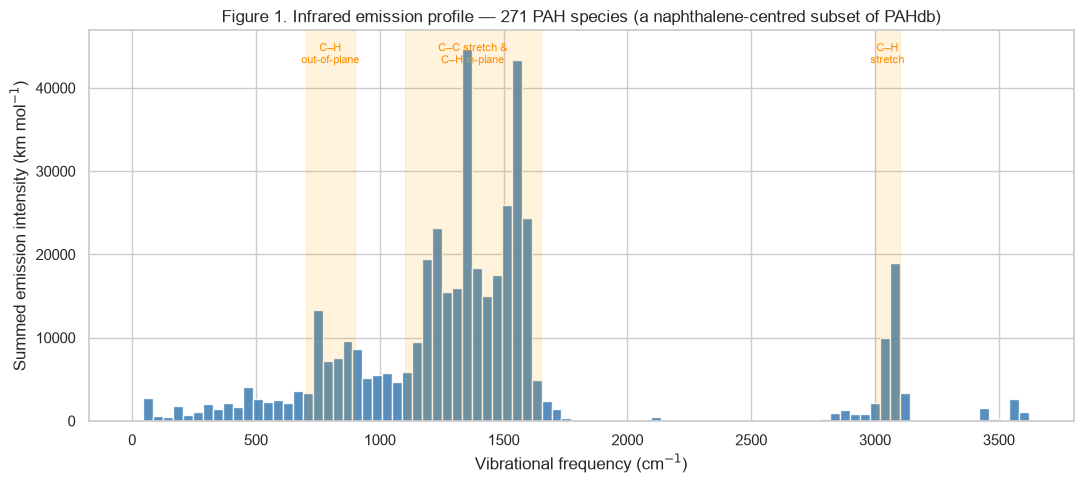

In [5]:
# Q1 VISUALIZATION: where the infrared EMISSION concentrates in frequency.
# Weight each line by its intensity, so the bars show emitted power per frequency bin
# (an "emission profile") rather than a raw count of modes. The characteristic PAH bands
# emerge from the data itself; the shaded regions simply name the peaks for the reader.
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(transitions["frequency"], bins=90, weights=transitions["intensity"],
        color="steelblue", edgecolor="white", alpha=0.9)
ymax = ax.get_ylim()[1]

# Shade and name the characteristic PAH emission bands (aligned with the emergent peaks).
bands = [
    (700, 900, "C–H\nout-of-plane"),
    (1100, 1650, "C–C stretch &\nC–H in-plane"),
    (3000, 3100, "C–H\nstretch"),
]
for lo, hi, label in bands:
    ax.axvspan(lo, hi, color="orange", alpha=0.13)
    ax.text((lo + hi) / 2, ymax * 0.97, label, ha="center", va="top",
            fontsize=8, color="darkorange")

ax.set_xlabel("Vibrational frequency (cm$^{-1}$)")
ax.set_ylabel("Summed emission intensity (km mol$^{-1}$)")
ax.set_title("Figure 1. Infrared emission profile — 271 PAH species (a naphthalene-centred subset of PAHdb)")
plt.tight_layout()
plt.show()


**Figure 1 — Observations.** With the lines weighted by intensity, the concentration is now visible directly in the bars: about **two-thirds of all emitted infrared power falls between ~1100 and 1650 cm⁻¹** — the aromatic **C–C stretching** and **C–H in-plane bending** bands (the "6–9 µm" features) — with smaller contributions from the **C–H stretch near 3050 cm⁻¹** and the **C–H out-of-plane bends around 700–900 cm⁻¹**. The **~1700–3000 cm⁻¹ region is essentially empty**. Two side effects worth noting: the IR-silent modes simply disappear here (zero intensity adds nothing), and because this subset is **cation-rich**, emission is pulled toward the 6–9 µm region — cations are known to emit strongly there. That charge dependence is exactly what we test in the bivariate section.


### Q2 — What ionization states make up the molecule set?

**What do neutral / cation / anion mean?** A molecule is **neutral** when its positive and negative charges balance out. If it **loses** an electron it becomes positively charged — a **cation**; if it **gains** an electron it becomes negatively charged — an **anion**. (In space, PAHs are ionized by ultraviolet starlight, which is why all three forms occur.) Because adding or removing an electron changes how charge is spread across the molecule, it changes how strongly each vibration emits infrared light — the effect we investigate in the bivariate and multivariate sections.

Ionization is therefore the property we expect to reshape the spectrum, so before comparing spectra we look at how many **neutral**, **cation**, and **anion** species we have. We use the species-level view (`molecules_species`, 271 rows) so isomer duplicates in the full table don't inflate the counts.


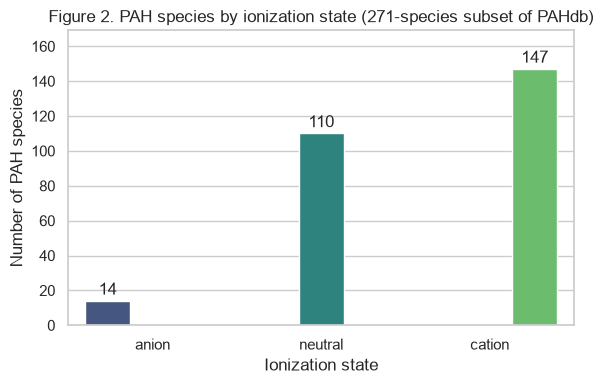

In [6]:
# Q2 VISUALIZATION: how many species of each ionization state (species level, n = 271).
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=molecules_species, x="charge_state", order=charge_order,
              hue="charge_state", palette="viridis", legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)
ax.set_xlabel("Ionization state")
ax.set_ylabel("Number of PAH species")
ax.set_title("Figure 2. PAH species by ionization state (271-species subset of PAHdb)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


**Figure 2 — Observations.** The set is dominated by **cations (147)** and **neutrals (110)**, with only **14 anions** — a strong class imbalance. Any later comparison across ionization states must treat the anion group cautiously (small sample), so we will prefer distributions and ratios over raw counts when contrasting charge states.


### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

The **emission profile** (frequency weighted by intensity) is strongly concentrated: most emitted power sits in the ~1100–1650 cm⁻¹ bands, with smaller peaks near 3050 and 700–900 cm⁻¹ and a genuine empty gap at ~1700–3000 cm⁻¹. The frequency axis itself needs no transformation (it is naturally bounded in cm⁻¹); the one deliberate choice was to **weight by intensity** rather than count modes, so the plot answers "where does emission concentrate?" instead of "how many modes exist?". A side note: the **15% of IR-silent lines** (intensity = 0, symmetry-forbidden modes) contribute nothing to this weighted view — we keep them in the data and will highlight them in the per-molecule fact-sheet spectrum.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

The **charge_state** distribution is notably imbalanced (147 / 110 / 14). We encoded it as an ordered categorical during preliminary wrangling so the count plot reads anion → neutral → cation, and used the **species-level** view (271 rows) so formula-based isomer duplicates don't inflate the counts. We also keep in mind that all of these figures describe a **naphthalene-centred subset** of PAHdb, not the full population.


## Bivariate Exploration

Having met the ingredients, we now combine them — first to see **what a spectrum actually is** (frequency together with intensity), then to test the central hypothesis that **ionization reshapes that spectrum**. We continue the Question → Visualization → Observations framework.

### Q3 — What does a PAH spectrum look like as frequency vs intensity?

A spectrum is exactly these two variables together: each emission line has a **frequency** (where it sits) and an **intensity** (how strong it is). Plotting all lines as frequency vs intensity gives the raw shape that a single molecule's fact-sheet spectrum is a slice of.


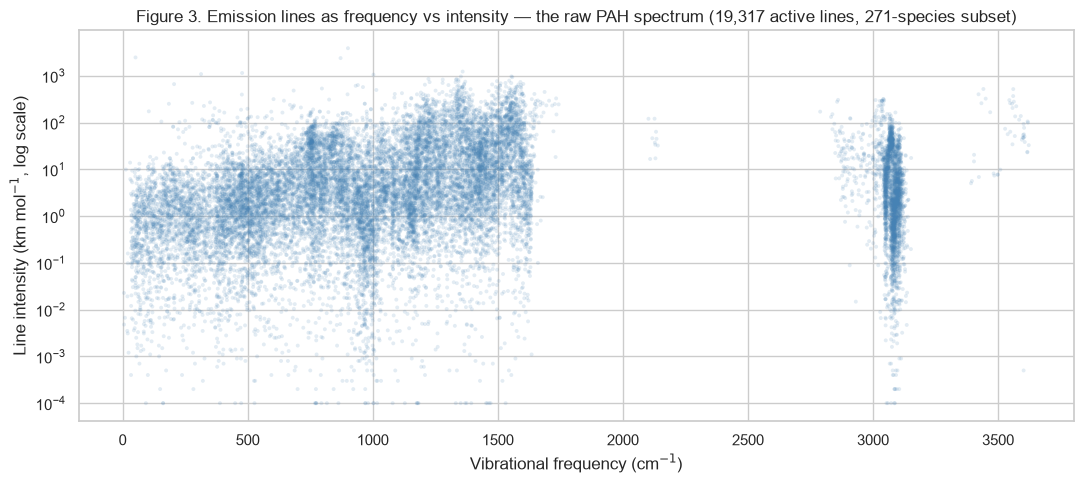

In [7]:
# Q3 VISUALIZATION: the spectrum itself - every emission line as frequency vs intensity.
active = transitions[transitions["intensity"] > 0]   # a log intensity axis needs intensity > 0

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(active["frequency"], active["intensity"], s=8, alpha=0.15,
           color="steelblue", edgecolors="none")
ax.set_yscale("log")
ax.set_xlabel("Vibrational frequency (cm$^{-1}$)")
ax.set_ylabel("Line intensity (km mol$^{-1}$, log scale)")
ax.set_title(f"Figure 3. Emission lines as frequency vs intensity — the raw PAH spectrum "
             f"({len(active):,} active lines, 271-species subset)")
plt.tight_layout()
plt.show()


**Figure 3 — Observations.** The cloud is not uniform: emission lines pile up into vertical stripes at the characteristic band frequencies (notably 1100–1650 and ~3050 cm⁻¹), and the strongest lines (top of the log axis) sit inside those bands. Away from the bands — especially the empty 1700–3000 cm⁻¹ gap — there are few lines and none strong. This is the raw material of every fact-sheet spectrum: a handful of strong lines in a few narrow regions, above a scatter of weak ones.


### Q4 — Does ionization change how much a molecule emits?

The introduction argued that ionization redistributes charge and so should change infrared emission. We test the simplest version first: **total** emission. For each species we sum the intensity of all its lines and compare the three ionization states with a box plot (log scale, since totals span a wide range).


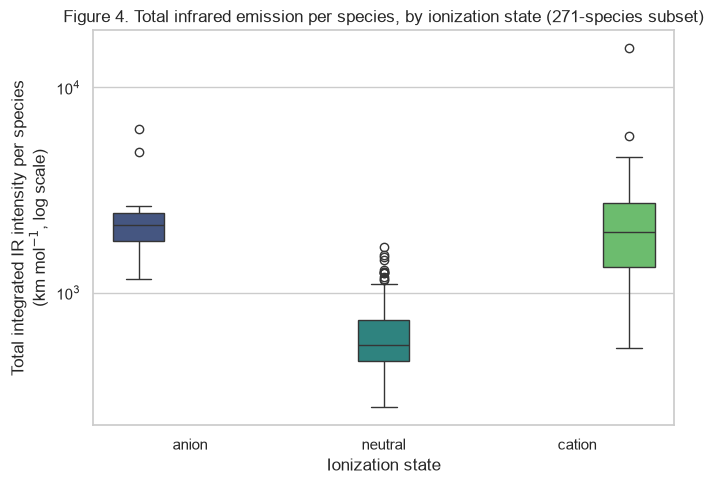

Median total intensity: {'anion': 2127, 'neutral': 554, 'cation': 1982}


In [8]:
# Q4 VISUALIZATION: total integrated IR emission per species, by ionization state.
species_emission = (
    transitions.groupby("uid")["intensity"].sum().rename("total_intensity").reset_index()
    .merge(molecules_species[["uid", "charge_state"]], on="uid")
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=species_emission, x="charge_state", y="total_intensity",
            order=charge_order, hue="charge_state", palette="viridis",
            legend=False, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Ionization state")
ax.set_ylabel("Total integrated IR intensity per species\n(km mol$^{-1}$, log scale)")
ax.set_title("Figure 4. Total infrared emission per species, by ionization state (271-species subset)")
plt.tight_layout()
plt.show()

medians = species_emission.groupby("charge_state", observed=True)["total_intensity"].median()
print("Median total intensity:", {k: round(v) for k, v in medians.items()})


**Figure 4 — Observations.** Ionization clearly matters: **cations and anions emit far more in total than neutrals** — median total intensity ≈ 1,980 (cation) and 2,130 (anion) versus only ≈ 554 for neutrals, a ~3–4× boost, with the neutral and ion boxes barely overlapping. So the mere presence of a net charge makes a PAH a much stronger infrared emitter — the well-known reason ionized PAHs dominate the emission seen from interstellar clouds. (The 14 anions are few, so we read their box cautiously.)


### Q5 — *Where* does each ionization state emit?

Total emission is only half the story: ionization also moves emission **between bands**. For each charge state we take the fraction of its total emission that falls in each characteristic band, and compare them in a heatmap.


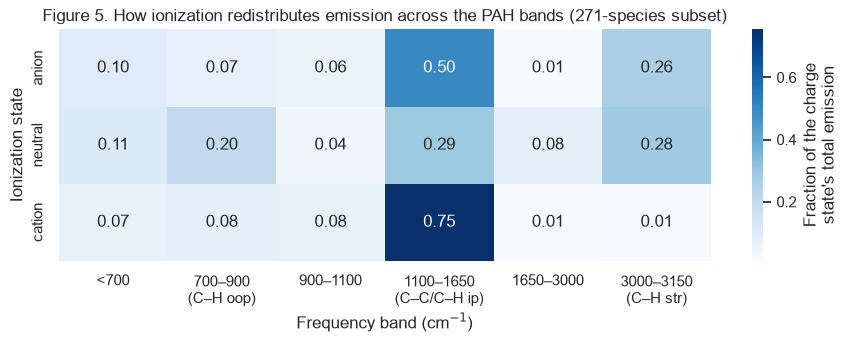

In [9]:
# Q5 VISUALIZATION: how each ionization state distributes its emission across the bands.
band_edges = [0, 700, 900, 1100, 1650, 3000, 3200]
band_labels = ["<700", "700–900\n(C–H oop)", "900–1100", "1100–1650\n(C–C/C–H ip)",
               "1650–3000", "3000–3150\n(C–H str)"]
tr_banded = transitions.merge(molecules_species[["uid", "charge_state"]], on="uid")
tr_banded["band"] = pd.cut(tr_banded["frequency"], bins=band_edges,
                           labels=band_labels, right=False)

# Aggregate emission per (charge_state, band), then normalise to a fraction per charge state.
band_totals = (tr_banded.groupby(["charge_state", "band"], observed=True)["intensity"]
               .sum().unstack()[band_labels])
band_frac = band_totals.div(band_totals.sum(axis=1), axis=0).reindex(charge_order)

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(band_frac, annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={"label": "Fraction of the charge\nstate's total emission"}, ax=ax)
ax.set_xlabel("Frequency band (cm$^{-1}$)")
ax.set_ylabel("Ionization state")
ax.set_title("Figure 5. How ionization redistributes emission across the PAH bands (271-species subset)")
plt.tight_layout()
plt.show()


**Figure 5 — Observations.** The redistribution is dramatic. **Cations** funnel ~**75%** of their emission into the **1100–1650 cm⁻¹ (6–9 µm)** bands and almost entirely lose the **3.3 µm C–H stretch (0.01)** — the classic "cations are 6–9 µm emitters" signature. **Neutrals** are far more balanced: they keep a strong **C–H stretch (0.28)** and **C–H out-of-plane band (0.20, the 11.3 µm feature)** alongside the 6–9 µm region. **Anions** resemble neutrals in retaining a strong 3.3 µm (0.26) but lean more toward 6–9 µm (0.50). So ionization changes not just *how much* a PAH emits but *where* — the same molecule would show a visibly different fact-sheet spectrum as a neutral versus a cation.


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

Our feature of interest — the emission lines' `frequency` and `intensity` — varies strongly with **ionization**. The frequency-vs-intensity scatter showed that strong emission is confined to a few bands. Splitting by `charge_state` then revealed two effects: (1) **total** emission is ~3–4× higher for ions (cations/anions) than neutrals, and (2) the **distribution across bands** shifts markedly — cations concentrate ~75% of emission in the 6–9 µm bands and lose the 3.3 µm C–H stretch, while neutrals retain strong 3.3 µm and 11.3 µm features. Ionization is therefore the dominant driver of a PAH's spectral appearance in this dataset.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

The clearest secondary pattern is the **anion ↔ neutral similarity** in band shape (both keep a strong 3.3 µm C–H stretch), which contrasts with the cation's very different profile — suggesting the loss of that band is specifically a *cation* effect rather than a generic "any charge" effect. We read this cautiously given only 14 anions. Molecular size (`MolecularWeight` / `HeavyAtomCount`) mainly sets the *number* of lines through the deterministic 3N − 6 rule discussed earlier, so we did not re-plot that relationship here.


## Multivariate Exploration

The bivariate section showed that ionization drives both *how much* and *where* PAHs emit. Here we bring in a third variable — first by viewing the emission spectrum **per ionization state** side by side (does the whole spectral shape really change?), then by adding **molecular size** to see whether it matters once charge is accounted for.

### Q6 — How does the emission spectrum itself differ between neutrals, cations, and anions?

The heatmap summarised band *fractions*; here we plot the full **emission profile** (intensity-weighted frequency) as three faceted panels, one per charge state, so the change in spectral *shape* is visible directly.


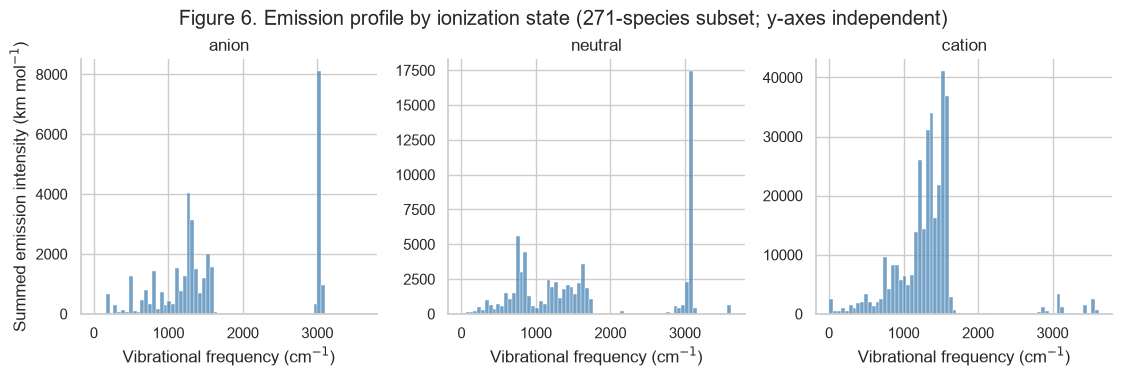

In [10]:
# Q6 VISUALIZATION: emission profile (intensity-weighted frequency) faceted by charge state.
tr_charge = transitions.merge(molecules_species[["uid", "charge_state"]], on="uid")

g = sns.displot(
    data=tr_charge, x="frequency", weights="intensity",
    col="charge_state", col_order=charge_order,
    bins=70, height=3.6, aspect=1.05, color="steelblue",
    facet_kws={"sharey": False},   # compare SHAPE; absolute totals differ (see box plot)
)
g.set_axis_labels("Vibrational frequency (cm$^{-1}$)", "Summed emission intensity (km mol$^{-1}$)")
g.set_titles("{col_name}")
g.figure.suptitle("Figure 6. Emission profile by ionization state (271-species subset; y-axes independent)",
                  y=1.03)
plt.show()


**Figure 6 — Observations.** The three spectra are visibly different kinds of light. **Neutrals** show a towering 3.3 µm **C–H stretch** spike (~3050 cm⁻¹) plus a broad spread across the 6–9 µm and 11.3 µm regions. **Anions** likewise keep a very strong 3.3 µm peak alongside substantial 6–9 µm emission. But **cations** almost entirely *lose* the 3.3 µm C–H stretch and pile their emission into the 6–9 µm (1100–1650 cm⁻¹) region. The clearest signature is thus the **near-absence of the 3.3 µm peak in cations**. (Y-axes are independent so the *shapes* can be compared; recall from the box plot that the ions' absolute emission is ~3–4× the neutrals'.) This is the fact-sheet payoff in miniature — the *same* molecule would present a visibly different spectrum depending on its charge.


### Q7 — Does molecular size matter once we account for charge?

We combine three variables in one view: molecular **size** (`MolecularWeight`, x-axis), **total emission** (y-axis, log), and **ionization** (colour), adding a **trend line per charge group** to reveal any size effect. This asks whether size adds anything to the charge story — while keeping a single colour encoding so the plot stays legible.


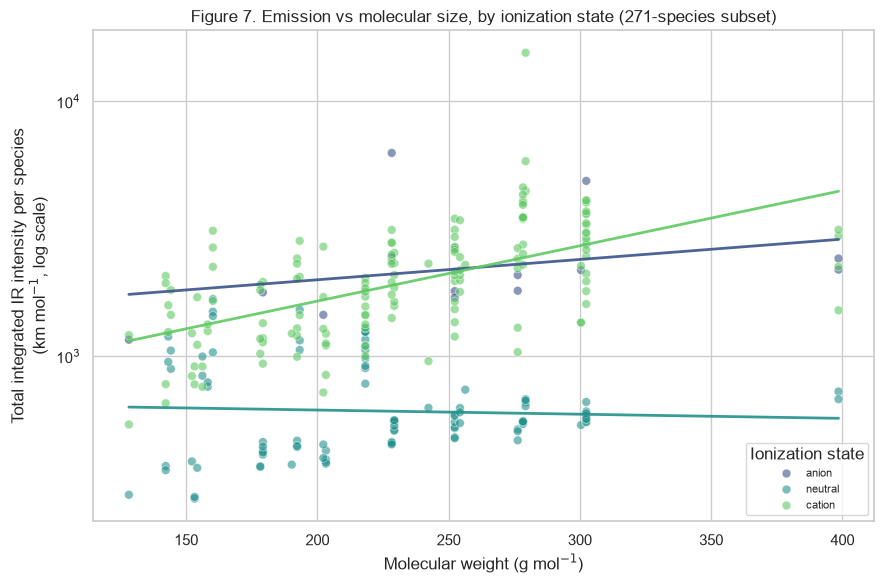

In [11]:
# Q7 VISUALIZATION: molecular size vs total emission, coloured by ionization state,
# with a per-charge trend line to expose the (weak) size effect within each group.
species_features = molecules_species[["uid", "charge_state", "MolecularWeight", "n_lines"]].merge(
    species_emission[["uid", "total_intensity"]], on="uid"
)

palette = dict(zip(charge_order, sns.color_palette("viridis", 3)))
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=species_features, x="MolecularWeight", y="total_intensity",
                hue="charge_state", hue_order=charge_order, palette=palette,
                alpha=0.6, s=40, ax=ax)

# Per-charge trend line, fitted in log space because the y-axis is logarithmic.
for cs in charge_order:
    grp = species_features[species_features["charge_state"] == cs]
    slope, intercept = np.polyfit(grp["MolecularWeight"], np.log10(grp["total_intensity"]), 1)
    xs = np.array([grp["MolecularWeight"].min(), grp["MolecularWeight"].max()])
    ax.plot(xs, 10 ** (intercept + slope * xs), color=palette[cs], lw=2, alpha=0.9)

ax.set_yscale("log")
ax.set_xlabel("Molecular weight (g mol$^{-1}$)")
ax.set_ylabel("Total integrated IR intensity per species\n(km mol$^{-1}$, log scale)")
ax.set_title("Figure 7. Emission vs molecular size, by ionization state (271-species subset)")
ax.legend(title="Ionization state", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


**Figure 7 — Observations.** Colour (charge) separates the points **vertically** far more than size moves them **horizontally**: neutrals sit low, cations and anions high, at every molecular weight — confirming that **ionization, not size, sets the emission level**. The per-charge **trend lines** expose the secondary size effect: mildly **positive for cations** (larger cations emit a little more) but essentially **flat for neutrals** — so size matters only weakly, and in a charge-dependent way. This is exactly the interaction a multivariate view is meant to reveal, and it stays legible with a single colour encoding rather than stacking marker size on top.

> **Note for the explanatory phase.** Even after dropping the marker-size channel, this plot is still fairly **busy** — three overlapping point clouds plus three trend lines. For Part II we should improve its readability, for example by letting the reader **focus on one ionization state at a time** (an interactive legend that keeps the selected charge bold and fades the others into the background).


### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

Charge state and molecular size act on emission together, but very unequally. The faceted spectra confirmed that **ionization reshapes the whole spectrum**, not just the totals. The multi-encoding scatter then showed that **once charge is accounted for, size adds only a weak, charge-dependent nudge** to total emission (mildly positive for cations, essentially flat for neutrals). So charge is the dominant feature and size is a secondary modifier that only becomes visible after controlling for charge — the two operate on very different scales rather than strongly reinforcing each other.

### Were there any interesting or surprising interactions between features?

The most interesting interaction is that the **sign of the size effect depends on charge** (positive for cations, ~flat/negative for neutrals) — size is not a simple universal driver of emission. A second, expected non-interaction: `n_lines` is essentially a deterministic function of size (the 3N − 6 rule, correlation ≈ 0.99), so encoding it separately mainly re-confirms that collinearity rather than revealing new structure.


## Toward the fact sheet: what the raw PAHdb XML can (and can't) give us

*(This section is stand-out groundwork for Part II — it is not one of the seven required exploratory visualizations.)*

**Why we need this.** The goal of Part II is a one-page "fact sheet" for a chosen molecule — a picture of the molecule next to its infrared spectrum — plus an interactive twist: **click a line in the spectrum and watch the atoms that produce it vibrate.** To build that, we need two ingredients that the *cleaned* data does **not** contain:

1. **Where the atoms are** — the 3D position of every atom, so we can *draw* the molecule.
2. **How the atoms move for each line** — for every spectral line, the direction each atom moves (its "displacement vector"), so we can *animate* the right vibration.

Our cleaned tables only list each line's frequency and intensity — not the atom positions, and not the motions. That information, if it exists anywhere, lives in the **original PAHdb XML**. So this spike opens that raw file and checks exactly what is — and isn't — available, before we promise any particular animation in Part II.


In [12]:
# SPIKE: inspect one molecule (naphthalene, uid 330) in the raw PAHdb XML to see whether
# it stores (a) atom geometry and (b) per-line atomic displacement vectors.
from lxml import etree

PAHDB_XML = DATA_DIR.parent / "raw" / "pahdb-complete-theoretical-v4.00.xml"
NS = "{http://www.astrochemistry.org/pahdb/theoretical}"


def find_specie(xml_path, target_uid):
    """Stream the XML and return the <specie> element whose uid matches (then stop)."""
    for _, specie in etree.iterparse(xml_path, events=("end",), tag=NS + "specie"):
        if specie.get("uid") == str(target_uid):
            return specie
        specie.clear()
    return None


naph = find_specie(PAHDB_XML, 330)               # neutral naphthalene, C10H8
geometry = naph.find(NS + "geometry")
modes = naph.find(NS + "transitions")
fields_per_mode = [f.tag.split("}")[-1] for f in list(modes[0])]

print("Geometry present? ", geometry is not None, "->", len(geometry), "atoms")
print("Transitions present?", modes is not None, "->", len(modes), "modes")
print("Fields stored per mode:", fields_per_mode)
print("\n=> Geometry is available, but a mode carries only frequency/intensity/symmetry,")
print("   NOT the per-atom displacement vectors an exact vibration animation would need.")


Geometry present?  True -> 18 atoms
Transitions present? True -> 48 modes
Fields stored per mode: ['frequency', 'intensity', 'symmetry']

=> Geometry is available, but a mode carries only frequency/intensity/symmetry,
   NOT the per-atom displacement vectors an exact vibration animation would need.


### What we found

- ✅ **Atom geometry is available.** Every species carries a `<geometry>` block: one `<atom>` per atom, each with a 3D position (`x`, `y`, `z`) and an element `type` (atomic number). So we *can* draw the real molecule.
- ❌ **Per-line displacement vectors are not.** Each vibrational `<mode>` stores only its `frequency`, `intensity`, and `symmetry` label — **not** how the individual atoms move. So the raw data does not tell us, for a given spectral line, which atoms move and in which direction.

This is the key result of the spike: **geometry yes, motions no.**


In [13]:
# Extract the 3D geometry of every molecule in our dataset and cache it for Part II.
# (Parsing the ~480 MB XML takes only a few seconds; we cache so re-runs are instant.)
import os

GEOM_PATH = DATA_DIR.parent / "processed" / "pah_geometry.csv"
Z_SYMBOL = {1: "H", 6: "C", 7: "N", 8: "O"}


def extract_geometry(xml_path, keep_uids):
    """Stream the XML once and return a tidy atom table for the requested species."""
    rows = []
    for _, sp in etree.iterparse(xml_path, events=("end",), tag=NS + "specie"):
        uid = sp.get("uid")
        if uid in keep_uids:
            geo = sp.find(NS + "geometry")
            if geo is not None:
                for atom in geo:
                    rows.append((
                        int(uid),
                        int(atom.findtext(NS + "position")),
                        int(atom.findtext(NS + "type")),
                        float(atom.findtext(NS + "x")),
                        float(atom.findtext(NS + "y")),
                        float(atom.findtext(NS + "z")),
                    ))
        sp.clear()                                  # free the parsed element
        while sp.getprevious() is not None:         # and its processed siblings (low memory)
            del sp.getparent()[0]
    df = pd.DataFrame(rows, columns=["uid", "atom_index", "atomic_number", "x", "y", "z"])
    df["element"] = df["atomic_number"].map(Z_SYMBOL)
    return df


if GEOM_PATH.exists():
    geometry_df = pd.read_csv(GEOM_PATH)
    print(f"Loaded cached geometry: {GEOM_PATH}")
else:
    os.makedirs(GEOM_PATH.parent, exist_ok=True)
    geometry_df = extract_geometry(PAHDB_XML, set(molecules["uid"].astype(str).unique()))
    geometry_df.to_csv(GEOM_PATH, index=False)
    print(f"Parsed XML and cached geometry -> {GEOM_PATH}")

print(f"{geometry_df['uid'].nunique()} molecules, {len(geometry_df):,} atoms, "
      f"elements {sorted(geometry_df['element'].unique())}")


Loaded cached geometry: ..\data\processed\pah_geometry.csv
271 molecules, 8,112 atoms, elements ['C', 'H', 'N', 'O']


### Bonus: we really can draw the molecule (a quick proof)

*(Bonus visual — not one of the seven required exploratory plots.)*

To confirm the geometry is usable, **Figure 8** shows neutral naphthalene rendered from the extracted coordinates: atoms coloured by element, bonds inferred from interatomic distances. This is the "structure" half of the Part II fact sheet.


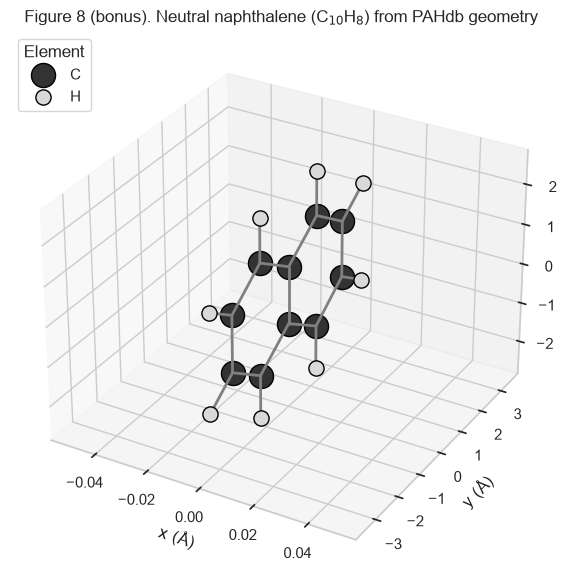

In [14]:
# Bonus: render naphthalene's 3D structure from the extracted geometry (atoms + inferred bonds).
from itertools import combinations

naph_atoms = geometry_df[geometry_df["uid"] == 330].reset_index(drop=True)
element_color = {"C": "0.2", "H": "0.85", "N": "royalblue", "O": "crimson"}
element_size = {"C": 300, "H": 120, "N": 320, "O": 320}
coords = naph_atoms[["x", "y", "z"]].to_numpy()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# Bonds: connect atom pairs closer than a typical bond length (~1.7 A).
for i, j in combinations(range(len(naph_atoms)), 2):
    if ((coords[i] - coords[j]) ** 2).sum() ** 0.5 < 1.7:
        ax.plot(*zip(coords[i], coords[j]), color="0.5", lw=2)

for elem, grp in naph_atoms.groupby("element"):
    ax.scatter(grp["x"], grp["y"], grp["z"], s=element_size[elem],
               c=element_color[elem], edgecolors="black", label=elem, depthshade=False)

ax.set_title("Figure 8 (bonus). Neutral naphthalene (C$_{10}$H$_8$) from PAHdb geometry")
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.legend(title="Element", loc="upper left")
plt.tight_layout()
plt.show()


### Can we at least tell *which* atoms move for a line? — and what it means for Part II

A natural follow-up: even without the exact motions, do we at least know *which* atoms move for a given line? From the data **directly, no** — a mode stores only frequency, intensity, and symmetry. We can only **infer a class** of atoms:

- **Frequency → vibration type → atom group:** a ~3050 cm⁻¹ line is a **C–H stretch** (the C–H units); ~1100–1650 cm⁻¹ is **C–C stretch / C–H in-plane** (ring carbons); ~700–900 cm⁻¹ is **C–H out-of-plane** (the hydrogens).
- **Symmetry label → orientation:** in a planar PAH, a double-prime label (e.g. `A"`) means **out-of-plane** motion, single-prime means **in-plane**.

But here is the crucial physics we have to be honest about: **a normal mode is collective.** For a given line it is *not* that "two atoms move" — it is a **weighted displacement of *every* atom at once** (many atoms each moving a little, in a specific pattern). So the very premise of the original stand-out idea — *"click a line and the corresponding atoms move"* — does not match reality: there is no small set of "the corresponding atoms." Even with the eigenvectors in hand, the honest picture is *all* atoms moving together.

**This means we must rethink the Part II objective.** The options range from a frankly **schematic** cue (animate the representative bond type for a line's band, clearly labelled as illustrative, not literal), to **recomputing the true normal modes ourselves** (a quantum-chemistry / force-field step — capstone scope), to **repurposing** the interactive idea toward something the data *can* support faithfully. This is an important finding, so we draw the full conclusion in the **Conclusions** section below.

The concrete, unambiguous deliverable this spike still hands to Part II is the extracted **geometry** (`data/processed/pah_geometry.csv`) — enough to *draw* every molecule, which the fact sheet needs regardless of how we resolve the animation question.


## Conclusions
>You can write a summary of the main findings and reflect on the steps taken during the data exploration.

> **Rubric Tip**: Create a list of summary findings to make it easy to review.

> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML.


> At the end of your report, make sure that you export the notebook as an html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep track of where the exported file goes, so you can put it in the same folder as this notebook for project submission. Also, make sure you remove all of the quote-formatted guide notes like this one before you finish your report!

